In [90]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
from scipy.optimize import minimize
from scipy.linalg import solve_discrete_are, block_diag
print("All imports OK")
print(f"CasADi version: {ca.__version__}")


All imports OK
CasADi version: 3.7.2


# 01 — Open-Loop Simulation: Double Integrator

This notebook simulates a **double integrator** in open loop using pure NumPy.

No classes, no CasADi, no abstractions. Everything is explicit and flat.

**System:**
The double integrator models a mass driven by a force input:
- State: x = [position, velocity]
- Input: u = [force/acceleration]

**Goal:** Run the full pipeline end-to-end:
Docker → JupyterLab → notebook → simulation → plot


In [91]:
## 1. Imports


## Functions to input

## Simple State Controller

Applies full-state feedback to compute the control input:

$$u_k =  -K\,(x_k - x_{\text{d},k})$$

- `K` — gain matrix (computed via LQR, see below)
- `x_d` — reference state trajectory

Returns `u_k` as control input.


In [92]:
def state_controller(x, xd):
    K  = np.array([[2.0, 1.0]])
    return -K @ (x - xd)


## LQR Controller

Solves the infinite-horizon discrete-time optimal control problem:

$$\min_{u} \sum_{k=0}^{\infty} \left( \tilde{x}_k^\top Q\, \tilde{x}_k + u_k^\top R\, u_k \right)$$

where $\tilde{x}_k = x_k - x_{d,k}$ is the state error, subject to $\tilde{x}_{k+1} = A \tilde{x}_k + B u_k$.

The optimal gain **K** is obtained via the solution **P** of the DARE:

$$P = Q + A^\top P A - A^\top P B\,(R + B^\top P B)^{-1} B^\top P A$$

$$K = (R + B^\top P B)^{-1} B^\top P A$$

**Cost weights (tunable):**
- `Q` — penalizes position error more than velocity
- `R` — penalizes control effort

Returns $u_k = -K\,\tilde{x}$.

> **Note:** K is recomputed at every call. Move outside the loop for efficiency.


In [93]:
def lqr_controller(x, xd, A, B):
    Q = np.diag([10.0, 1.0])  # state cost: penalize position more
    R = np.array([[1.0]])      # input cost

    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)

    return -K @ (x - xd)


## Finite-Horizon LQR & Terminal Cost

### 1. Truncated LQR

Finite-horizon version of LQR over $N$ steps, with no terminal cost:

$$\min_{u} \sum_{k=0}^{N-1} \left( \tilde{x}_k^\top Q\, \tilde{x}_k + u_k^\top R\, u_k \right)$$

subject to $\tilde{x}_{k+1} = A \tilde{x}_k + B u_k$, and $P_N = 0$.

Solved via backward Riccati recursion from $k = N-1$ to $k = 0$:

$$P_k = Q + A^\top P_{k+1} A - A^\top P_{k+1} B\,(R + B^\top P_{k+1} B)^{-1} B^\top P_{k+1} A$$

$$K_k = (R + B^\top P_{k+1} B)^{-1} B^\top P_{k+1} A$$

Performance degrades for small $N$ — the controller "gives up" near the end of the horizon.

---

### 2. Heuristic Terminal Cost

Replace $P_N = 0$ with a scaled state cost:

$$P_N = \alpha Q, \quad \alpha > 0$$

This penalizes the terminal state, improving performance for small $N$.  
However, $\alpha$ is a free tuning parameter — there is no principled way to choose it.

---

### 3. Optimal Terminal Cost via DARE

The optimal choice is $P_N = P_\infty$, the solution to the DARE:

$$P_\infty = Q + A^\top P_\infty A - A^\top P_\infty B\,(R + B^\top P_\infty B)^{-1} B^\top P_\infty A$$

$P_\infty$ represents the exact cost-to-go for the infinite tail beyond the horizon.  
With this terminal cost, the finite-horizon solution **recovers infinite-horizon performance** even for small $N$.


In [94]:
def mpc_ca_controller(x, xd, A, B, Ulim, Xlim):
    N  = 10                        # prediction horizon
    Q  = np.diag([10.0, 1.0])     # state cost
    R  = np.array([[1.0]])         # input cost
    QN = Q                         # terminal cost (use Q for now)

    nx = A.shape[0]
    nu = B.shape[1]

    # Decision variables
    X_var = ca.MX.sym('X', nx, N + 1)
    U_var = ca.MX.sym('U', nu, N)

    cost        = 0
    constraints = []

    # Initial condition constraint
    constraints.append(X_var[:, 0] - x)

    for k in range(N):
        e = X_var[:, k] - xd
        cost += e.T @ Q @ e + U_var[:, k].T @ R @ U_var[:, k]
        x_next = A @ X_var[:, k] + B @ U_var[:, k]
        constraints.append(X_var[:, k + 1] - x_next)

    # Terminal cost
    eN = X_var[:, N] - xd
    cost += eN.T @ QN @ eN

    # Flatten constraints
    g = ca.vertcat(*constraints)

    # Bounds
    lbx = -ca.inf * ca.DM.ones(X_var.numel() + U_var.numel())
    ubx =  ca.inf * ca.DM.ones(X_var.numel() + U_var.numel())

    # Input constraints
    u_start = X_var.numel()
    for k in range(N):
        lbx[u_start + k] = Ulim[0, 0]
        ubx[u_start + k] = Ulim[0, 1]

    # NLP
    nlp = {
        'x': ca.vertcat(ca.vec(X_var), ca.vec(U_var)),
        'f': cost,
        'g': g
    }
    opts = {'ipopt.print_level': 0, 'print_time': 0}
    solver = ca.nlpsol('solver', 'ipopt', nlp, opts)

    sol = solver(
        x0  = ca.DM.zeros(X_var.numel() + U_var.numel()),
        lbx = lbx,
        ubx = ubx,
        lbg = ca.DM.zeros(g.numel()),
        ubg = ca.DM.zeros(g.numel())
    )

    U_opt = np.array(sol['x'][X_var.numel():X_var.numel() + nu]).flatten()
    return U_opt.reshape(1, nu)


In [95]:
def mpc_controller(x, xd, A, B, Ulim, Xlim):
    N  = 10
    Q  = np.diag([10.0, 1.0])
    R  = np.array([[1.0]])
    QN = Q

    nx = A.shape[0]
    nu = B.shape[1]

    # --- Build prediction matrices ---
    Sx = np.zeros((nx * (N + 1), nx))
    Su = np.zeros((nx * (N + 1), nu * N))

    Ak = np.eye(nx)
    for k in range(N + 1):
        Sx[k*nx:(k+1)*nx, :] = Ak
        Ak = Ak @ A

    for k in range(N):
        Ak = np.eye(nx)
        for j in range(k, N):
            Su[(j+1)*nx:(j+2)*nx, k*nu:(k+1)*nu] += Ak @ B
            Ak = Ak @ A

    # --- Build cost matrices ---
    Q_bar = block_diag(*([Q] * N + [QN]))
    R_bar = np.kron(np.eye(N), R)

    # Reference vector — next N+1 steps of trajectory
    Xd_vec = xd.flatten()   # shape (nx*(N+1),)

    # --- Cost function ---
    def cost(U_flat):
        X_pred = Sx @ x + Su @ U_flat
        e = X_pred - Xd_vec
        return e @ Q_bar @ e + U_flat @ R_bar @ U_flat

    # --- Input constraints (bounds) ---
    bounds = [(Ulim[0, 0], Ulim[0, 1])] * (N * nu)

    # --- State constraints ---
    state_constraints = []
    for i in range(nx):
        for k in range(1, N + 1):
            row = Su[k*nx + i, :].copy()
            rhs = float((Sx @ x)[k*nx + i])
            lb  = float(Xlim[i, 0])
            ub  = float(Xlim[i, 1])
            state_constraints.append({
                'type': 'ineq',
                'fun': lambda U_flat, r=row, b=rhs, l=lb: (r @ U_flat + b) - l
            })
            state_constraints.append({
                'type': 'ineq',
                'fun': lambda U_flat, r=row, b=rhs, u=ub: u - (r @ U_flat + b)
            })

    # --- Solve ---
    U0     = np.zeros(N * nu)
    result = minimize(cost, U0, method='SLSQP', bounds=bounds, constraints=state_constraints)
    if not result.success:
        print(f"MPC warning: {result.message}")

    return result.x[:nu].reshape(1, nu)


In [96]:
def plot_results(X, U, Xd, Xlim, Ulim, nSteps, dt):
    t = np.arange(nSteps + 1) * dt

    fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

    axes[0].plot(t, X[:, 0], label='position')
    axes[0].plot(t, Xd[:nSteps+1, 0], 'k--', label='reference')
    axes[0].set_ylabel('Position [m]')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, X[:, 1], label='velocity', color='orange')
    axes[1].plot(t, Xd[:nSteps+1, 1], 'k--', label='reference')
    axes[1].set_ylabel('Velocity [m/s]')
    axes[1].grid(True)
    axes[1].legend()

    axes[2].step(t[:-1], U[:, 0], label='input (u=0)', color='green', where='post')
    axes[2].set_ylabel('Input u')
    axes[2].set_xlabel('Time [s]')
    axes[2].grid(True)
    axes[2].legend()

    axes[0].axhline(Xlim[0, 0], color='r', linestyle='--', linewidth=0.8, label='bounds')
    axes[0].axhline(Xlim[0, 1], color='r', linestyle='--', linewidth=0.8)

    axes[1].axhline(Xlim[1, 0], color='r', linestyle='--', linewidth=0.8, label='bounds')
    axes[1].axhline(Xlim[1, 1], color='r', linestyle='--', linewidth=0.8)

    axes[2].axhline(Ulim[0, 0], color='r', linestyle='--', linewidth=0.8, label='bounds')
    axes[2].axhline(Ulim[0, 1], color='r', linestyle='--', linewidth=0.8)


    plt.suptitle('Double Integrator — Open-Loop Simulation', fontsize=13)
    plt.tight_layout()
    plt.show()


## 2. System Definition

Discrete-time state-space model:

$$x_{k+1} = A x_k + B u_k$$

For a double integrator with sampling time $\Delta t$:

$$A = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}, \quad B = \begin{bmatrix} \frac{\Delta t^2}{2} \\ \Delta t \end{bmatrix}$$

Wait — for a simple Euler-discretized single-input double integrator:

$$A = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}, \quad B = \begin{bmatrix} 0 \\ \Delta t \end{bmatrix}$$


In [97]:
dt = 0.1  # sampling time [s]

A = np.array([[1, dt],
              [0,  1]])

B = np.array([[0  ],
              [dt ]])

nx = 2   # number of states
nu = 1   # number of inputs

print("A =", A)
print("B =", B)


A = [[1.  0.1]
 [0.  1. ]]
B = [[0. ]
 [0.1]]


## 3. Simulation Setup

Define the initial condition, input sequence, and simulation horizon.


In [98]:
nSteps  = 100          # number of simulation steps
x0 = np.array([8.0, 0.0])   # initial state: position=0, velocity=1

# Constant zero input (open loop — no control action)
U = np.zeros((nSteps, nu))

# Storage
X = np.zeros((nSteps + 1, nx))
X[0] = x0

# Bounds and Goal
# Goal and Bounds
# Xd = np.zeros((nSteps + 1, nx))
Ulim = np.array([[-4.0, 4.0]])   # (nu, 2) — one row per input
Xlim = np.array([[-10.0,   10.0],    # (nx, 2) — one row per state
                 [-5.0,   5.0]])

# Generate reference trajectory using LQR
Xd = np.zeros((nSteps + 20+1, nx))
Xd[0] = np.array([5.0, 0.0])  # or whatever start you want as "ideal"

for k in range(nSteps+20):
    u = lqr_controller(Xd[k], np.array([4*np.sin(k/15), 0.0]), A, B)  # some final target #REMARK: 5*np.sin is already in saturation, 4 not
    Xd[k+1] = A @ Xd[k] + B @ u
Xd_vec = Xd.flatten()   # already (N+1)*nx long



## 4. Simulation Loop

Manually propagate the state forward using the state-space equation.


### State Feedback

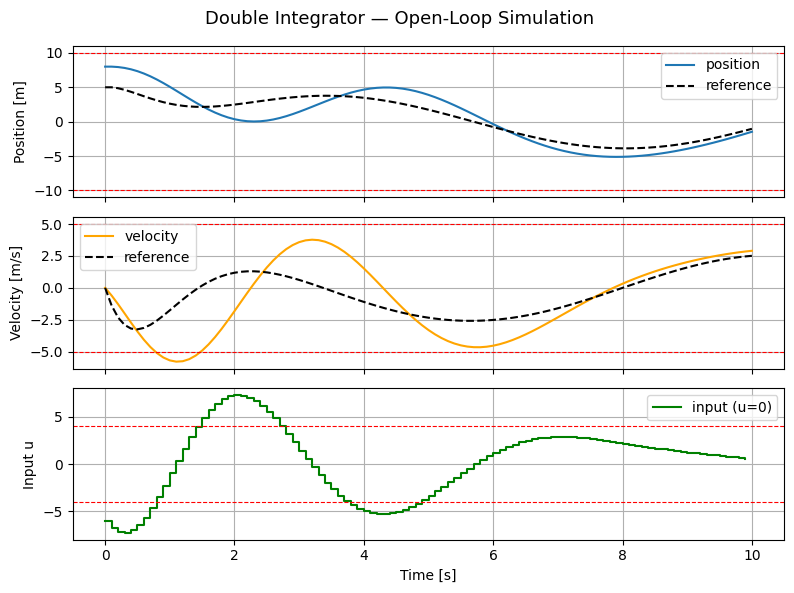

In [99]:
for k in range(nSteps):
    U[k] = state_controller(X[k], Xd[k])
    #U[k] = lqr_controller(X[k], Xd[k], A, B)
    #N = 10
    #U[k] = mpc_controller(X[k], Xd[k:k+N+1, :], A, B, Ulim, Xlim)
    # Limit control input
    #U[k] = np.clip(U[k], Ulim[:, 0], Ulim[:, 1])
    # System dynamics
    X[k+1] = A @ X[k] + B @ U[k]

plot_results(X, U, Xd, Xlim, Ulim, nSteps, dt)



### State Feedback using LQR

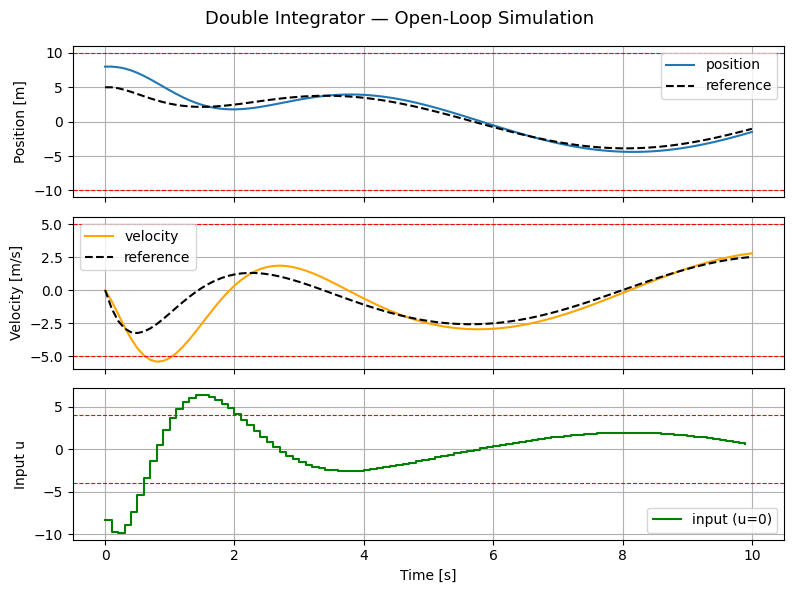

In [100]:
for k in range(nSteps):
    #U[k] = state_controller(X[k], Xd[k])
    U[k] = lqr_controller(X[k], Xd[k], A, B)
    #N = 10
    #U[k] = mpc_controller(X[k], Xd[k:k+N+1, :], A, B, Ulim, Xlim)
    # Limit control input
    #U[k] = np.clip(U[k], Ulim[:, 0], Ulim[:, 1])
    # System dynamics
    X[k+1] = A @ X[k] + B @ U[k]

plot_results(X, U, Xd, Xlim, Ulim, nSteps, dt)



## From LQR to MPC

### 1. LQR (Recap)

Optimal infinite-horizon controller for unconstrained linear systems.  
Returns an explicit gain $K$ — no online optimization needed.  
**Limitation:** cannot handle input or state constraints.

---

### 2. Input Constraints & LQR

Applying hard saturation to the LQR input violates the assumptions under
which $K$ was derived — the closed-loop is no longer optimal and may
perform poorly or become unstable.  
**Message:** clipping $u$ is not a solution. Constraints must enter the problem.

---

### 3. Constrained OCP (Infinite Horizon)

Incorporate constraints directly into the optimization:

$$\min_{u_0, u_1, \ldots} \sum_{k=0}^{\infty} \left( \tilde{x}_k^\top Q\, \tilde{x}_k + u_k^\top R\, u_k \right) \quad \text{s.t.} \quad \tilde{x}_{k+1} = A\tilde{x}_k + Bu_k, \quad u_k \in \mathcal{U}$$

Constraints are respected — but the infinite horizon makes this numerically intractable.

---

### 4. Truncated Horizon ($P_N = 0$)

Cut the cost at $N$ steps:

$$\min_{u_0,\ldots,u_{N-1}} \sum_{k=0}^{N-1} \left( \tilde{x}_k^\top Q\, \tilde{x}_k + u_k^\top R\, u_k \right) \quad \text{s.t.} \quad \tilde{x}_{k+1} = A\tilde{x}_k + Bu_k, \quad u_k \in \mathcal{U}$$

Constraints are satisfied, but the terminal state $\tilde{x}_N$ is ignored —
the controller "gives up" near the end of the horizon.  
Solution drifts from LQR for small $N$.

---

### 5. Heuristic Terminal Cost ($P_N = \alpha Q$)

Add a terminal penalty $\tilde{x}_N^\top P_N \tilde{x}_N$ with $P_N = \alpha Q$.  
Performance improves, but $\alpha$ requires manual tuning — no principled choice exists.

---

### 6. Optimal Terminal Cost ($P_N = P_\infty$)

Set $P_N = P_\infty$, the solution to the DARE.  
$P_\infty$ captures the exact cost-to-go for the infinite tail beyond the horizon.

**Key result:** unconstrained MPC with $P_N = P_\infty$ recovers the
infinite-horizon LQR solution exactly, for any $N$.  
When constraints are active, MPC goes beyond what LQR can achieve.


### State Feedback using MPC

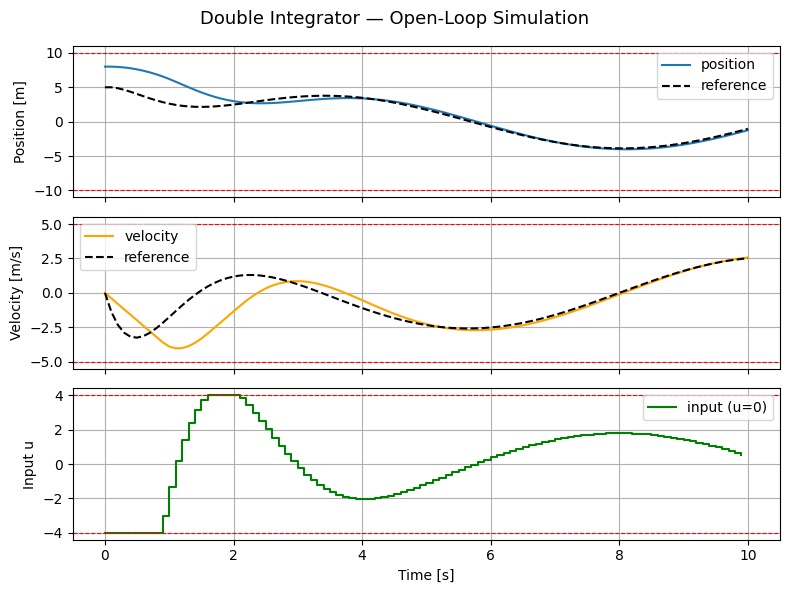

In [101]:
for k in range(nSteps):
    U[k] = state_controller(X[k], Xd[k])
    #U[k] = lqr_controller(X[k], Xd[k], A, B)
    N = 10
    U[k] = mpc_controller(X[k], Xd[k:k+N+1, :], A, B, Ulim, Xlim)
    # Limit control input
    #U[k] = np.clip(U[k], Ulim[:, 0], Ulim[:, 1])
    # System dynamics
    X[k+1] = A @ X[k] + B @ U[k]

plot_results(X, U, Xd, Xlim, Ulim, nSteps, dt)

